In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
import scipy

### Load data
I used a MovieLens dataset for traing and testing the our models.
I used it beacuse there are oue needed information like user movie and its ratings given by that particular user.
And also sparse (~94% empty) with a long-tailed item popularity, which is exactly the regime where the memory-vs-model trade-off is interesting.

dataset contains : MovieLens 100K movie ratings. Stable benchmark dataset. 100,000 ratings from 1000 users on 1700 movies. Released 4/1998.

In [3]:
import os, zipfile,urllib,io 

In [16]:
data = pd.read_csv('moviedata.csv')
data.head()

,Unnamed: 0,user,item,rating,ts
0,0,0,0,3,881250949
1,1,1,1,3,891717742
2,2,2,2,1,878887116
3,3,3,3,2,880606923
4,4,4,4,1,886397596


In [17]:
data = data.drop(columns=['Unnamed: 0','ts'])

In [13]:
data['user'].unique().shape
### there are 943 users who are rated movie or movies

(943,)

In [ ]:
data.info() ## there are no missing values. all cloumns datatype are in int64

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   user    100000 non-null  int64
 1   item    100000 non-null  int64
 2   rating  100000 non-null  int64
dtypes: int64(3)
memory usage: 2.3 MB


In [21]:
## Some Exploratory Analysis

## check duplicate user with same item(movie)
data.duplicated(["user", "item"]).sum() ## there are no duplicated value

np.int64(0)

<Axes: xlabel='rating', ylabel='user'>

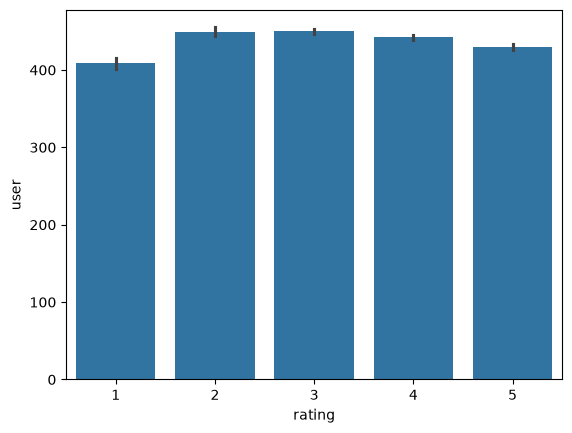

In [22]:
sns.barplot(data=data,x='rating',y='user')

<Axes: ylabel='Count'>

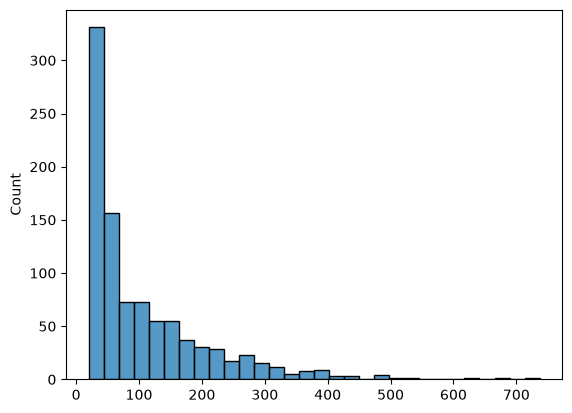

In [ ]:
u_cnt, i_cnt = data.groupby("user").size(), data.groupby("item").size()
sns.histplot(u_cnt,bins=30)

In [ ]:
## Split in between Train test and validation

def per_user_split(d, fracs=(.8, .1, .1), seed=42):
    r = np.random.default_rng(seed); parts = {"train": [], "val": [], "test": []}
    for _, g in d.groupby("user"):
        idx = r.permutation(len(g)); n = len(g)
        n_te = max(1, int(round(fracs[2] * n))); n_va = max(1, int(round(fracs[1] * n)))
        te, va, tr = idx[:n_te], idx[n_te:n_te + n_va], idx[n_te + n_va:]
        for k, ix in zip(["train", "val", "test"], [tr, va, te]): parts[k].append(g.iloc[ix])
    return {k: pd.concat(v).reset_index(drop=True) for k, v in parts.items()}

S = per_user_split(data)
train, val, test = S["train"], S["val"], S["test"]
trval = pd.concat([train, val]).reset_index(drop=True)

In [31]:
val

,user,item,rating
0,0,431,5
1,0,665,3
2,0,521,1
3,0,329,4
4,1,380,4
...,...,...,...
9983,941,807,3
9984,941,4,4
9985,941,48,3
9986,942,141,3
